# Tier-3 prototype — forcing-composition-dependent feedback $\Delta\lambda_\text{aero}$

Third notebook in the pattern-mediated-feedback series.

> **What Tier 3 does and doesn't change.** Tier 3 is a **feedback change**, not a forcing rescaling. The thermal model's radiative damping coefficient itself (`rlamda` = $1/\lambda_\text{pamset}$, the term that multiplies $T$ in the TOA balance) becomes time-varying as a function of the current forcing composition. The forcing input is unchanged — we feed the unweighted $F_\text{tot}$ straight into the energy balance.
>
> Unlike Tier 1 (notebook 02), this is a genuine new physical mechanism inside the model, not a forcing relabel. The diagnosed $\lambda_\text{diff}(t)$ varies because the model's actual feedback varies — so it would still show up no matter what reference forcing you used in the Gregory regression. That's the structural difference from Tier 1's diagnostic-artefact time variation.
>
> $\Delta T(t)$ under Tier 3 also responds differently from Tier 1: the fingerprint collapses back to zero difference in the far future as $w_\text{aero} \to 0$, rather than locking in a permanent offset from the aerosol-unmasking mechanism.

## Formulation

Per `../../pattern_mediated_feedback_scm.md` §5 and §7, replace the constant feedback with a time-varying one that tracks the forcing composition:

$$\lambda_\text{eff}(t) \;=\; \lambda_0 + \Delta\lambda_\text{aero}\,w_\text{aero}(t), \qquad w_\text{aero}(t) \;=\; \frac{|F_\text{aero}(t)|}{\sum_j |F_j(t)|}$$

using the magnitude-weighted aerosol fraction (brief §5.5 — avoids the division-by-zero problem when $F_\text{tot}$ crosses through zero around 1950–1970).

Unlike Tier 1, we don't modify the forcing that drives the energy balance — we modify the feedback itself. The thermal model's $R$-vs-$T$ Gregory slope is then genuinely time-varying with aerosol *fraction*, not with $dF_\text{aero}/dT$.

## Implementation — subclass the thermal model

The upwelling-diffusion model caches `rlamda` ($= 1/\lambda_\text{pamset}$ = the feedback in W m$^{-2}$ K$^{-1}$) in several derived quantities:
- `pamset['fnx']`, `pamset['fsx']` — used in the atmospheric temperature solver
- `self.gamn`, `self.gams` — used in `get_gam_and_fro_factor_ns`
- `self.varrying['dtrm*']` — per-step solver coefficients from `setup_ebud`

To update the feedback each year we refresh all of these. `setup_ebud()` recomputes the whole set, so calling it after overwriting `rlamda`/`fnx`/`fsx` is sufficient.

No source-code changes needed — we subclass the thermal model in the notebook and inject it via `cscm.thermal_model_class` before the run.

## Prediction (contrast with Tier 1)

- The diagnosed $\lambda_\text{diff}(t)$ should track $w_\text{aero}(t)$ rather than $dF_\text{aero}/dT$. Scatter against $w_\text{aero}$ should be **clean and monotonic** (Tier 1 produced a looser, signed-inconsistent scatter).
- A plateau in $F_\text{aero}$ with large aerosol fraction will preserve the feedback shift (Tier 1 would snap back to $1/\lambda_\text{pamset}$ because its variation lives in the derivative).
- Positive $\Delta\lambda_\text{aero}$ ⇒ stronger feedback during aerosol era ⇒ higher diagnosed $\lambda_\text{diff}$ then. Negative $\Delta\lambda_\text{aero}$ ⇒ weaker feedback during aerosol era ⇒ lower diagnosed $\lambda_\text{diff}$ — which is the direction AMIP diagnostics go in.

We sweep $\Delta\lambda_\text{aero}$ through both signs and compare against the CMIP6 AMIP schematic envelope.

## Imports, setup, helpers

In [4]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
TEST_DATA = os.path.join(REPO_ROOT, 'tests', 'test-data')

from ciceroscm import CICEROSCM
from ciceroscm.input_handler import read_components, read_inputfile, read_natural_emissions
from ciceroscm.thermal_model.upwelling_diffusion_model import UpwellingDiffusionModel

NYSTART, NYEND = 1750, 2300
LAMBDA_PAMSET = 0.54
AEROSOL_TRACERS = ['SO4_DIR', 'SO4_IND', 'BC', 'OC', 'NOx', 'NMVOC', 'NH3', 'BMB_AEROS']

def lambda_diff(T, R, window):
    T = np.asarray(T); R = np.asarray(R)
    out = np.full_like(T, np.nan, dtype=float)
    half = window // 2
    for i in range(half, len(T) - half):
        t_seg = T[i - half: i + half + 1]
        r_seg = R[i - half: i + half + 1]
        v = np.var(t_seg)
        if v <= 0:
            continue
        out[i] = -np.cov(t_seg, r_seg, ddof=0)[0, 1] / v
    return out

years = np.arange(NYSTART, NYEND + 1)

In [5]:
gaspam = read_components(os.path.join(TEST_DATA, 'gases_v1RCMIP.txt'))
df_nat_ch4 = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_ch4.txt'), 'CH4')
df_nat_n2o = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_n2o.txt'), 'N2O')
df_ssp2_conc = read_inputfile(os.path.join(TEST_DATA, 'ssp245_conc_RCMIP.txt'))
emi_input = read_inputfile(os.path.join(TEST_DATA, 'ssp245_em_RCMIP.txt'))
emi_input.rename(columns={'CO2': 'CO2_FF', 'CO2.1': 'CO2_AFOLU'}, inplace=True)

COMMON_UDM = dict(
    threstemp=7.0, rlamdo=16.0, akapa=0.634, cpi=0.4,
    W=4, beto=3.5, mixed=60.0, foan=0.61, foas=0.81,
    ebbeta=0.0, fnso=0.7531, lm=40, ldtime=12,
)
COMMON_UDM['lambda'] = LAMBDA_PAMSET

## Baseline run — extract $F_\text{tot}(t)$ and $w_\text{aero}(t)$

In [6]:
cscm_base = CICEROSCM({
    'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
    'nystart': NYSTART, 'nyend': NYEND,
    'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
    'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
})
cscm_base._run(
    {'results_as_dict': True, 'carbon_cycle_outputs': True},
    pamset_udm=dict(COMMON_UDM),
    pamset_emiconc={
        'qbmb': 0.0, 'qo3': 0.5, 'qdirso2': -0.00308,
        'qindso2': -0.97 / 57.052577209999995,
        'qbc': 0.0279, 'qoc': -0.00433, 'qh2o_ch4': 0.091915,
        'ref_yr': 2010,
    },
)

baseline_forc = pd.DataFrame(cscm_base.results['forcing']).set_index('Year')
F_tot = baseline_forc['Total_forcing']
F_aero = baseline_forc[AEROSOL_TRACERS].sum(axis=1)
F_abs_tot = baseline_forc.drop(columns=['Total_forcing']).abs().sum(axis=1)
# Pre-industrial baseline (1750) has zero forcing → zero-over-zero; set w_aero=0 there
w_aero = (F_aero.abs() / F_abs_tot).fillna(0.0)
print(f'w_aero peaks at {w_aero.max():.3f} in {w_aero.idxmax()}; NaNs: {int(w_aero.isna().sum())}')

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance
emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


w_aero peaks at 0.511 in 1970; NaNs: 0


## Tier-3 thermal model subclass

Adds one parameter (`delta_lambda_aero`) and reads a year-indexed $w_\text{aero}(t)$ via a class-level attribute set by the driver. Before each year's `energy_budget` call, it updates `rlamda` and calls the base class's `setup_ebud()` to refresh all dependent coefficients.

In [7]:
class Tier3UpwellingDiffusionModel(UpwellingDiffusionModel):
    thermal_model_required_pamset = {
        **UpwellingDiffusionModel.thermal_model_required_pamset,
        'delta_lambda_aero': 0.0,
    }

    # Set by the driver before a run. np.ndarray indexed [t-NYSTART].
    _w_aero_by_year = None

    def __init__(self, params=None):
        super().__init__(params)
        # Baseline feedback from the starting pamset (1/lambda_pamset)
        self.rlamda_baseline = self.pamset['rlamda']
        self._t_index = 0

    def _refresh_feedback(self, lambda_eff):
        self.pamset['rlamda'] = lambda_eff
        self.pamset['fnx'] = (
            lambda_eff + self.pamset['foan'] * self.pamset['rlamdo'] + self.pamset['ebbeta']
        )
        self.pamset['fsx'] = (
            lambda_eff + self.pamset['foas'] * self.pamset['rlamdo'] + self.pamset['ebbeta']
        )
        self.setup_ebud()  # refreshes gamn, gams, self.varrying[*]

    def energy_budget(self, forc_nh, forc_sh, fn_volc, fs_volc):
        w = 0.0
        if (self._w_aero_by_year is not None
                and self._t_index < len(self._w_aero_by_year)):
            w_raw = float(self._w_aero_by_year[self._t_index])
            if not np.isnan(w_raw):
                w = w_raw
        dlam = self.pamset.get('delta_lambda_aero', 0.0)
        lambda_eff = self.rlamda_baseline + dlam * w
        self._refresh_feedback(lambda_eff)
        self._t_index += 1
        return super().energy_budget(forc_nh, forc_sh, fn_volc, fs_volc)

## Driver

Uses `rf_run` mode with the *unweighted* $F_\text{tot}$. The thermal model itself is what varies — not the forcing input.

In [8]:
def make_forcing_df(F_series):
    return pd.DataFrame({'total': F_series.values,
                         'FORC_NH': F_series.values,
                         'FORC_SH': F_series.values},
                        index=F_series.index.astype(int))

def tier3_run(delta_lambda_aero, w_series=w_aero, F_series=F_tot):
    Tier3UpwellingDiffusionModel._w_aero_by_year = w_series.values
    cscm = CICEROSCM({
        'forc_data': make_forcing_df(F_series),
        'nystart': NYSTART, 'nyend': NYEND, 'idtm': 24,
    })
    cscm.thermal_model_class = Tier3UpwellingDiffusionModel
    pamset_udm = dict(COMMON_UDM)
    pamset_udm['delta_lambda_aero'] = delta_lambda_aero
    cscm._run({'results_as_dict': True}, pamset_udm=pamset_udm)
    T = np.asarray(cscm.results['dT_glob']).squeeze()
    N = np.asarray(cscm.results['RIB_glob']).squeeze()
    R = N - F_tot.values     # unweighted reference ERF
    return pd.DataFrame({'T': T, 'N': N, 'R': R},
                        index=pd.Index(years, name='year'))

# Sanity check: delta = 0 should recover the constant-lambda baseline
sanity = tier3_run(0.0)
T_b = np.asarray(cscm_base.results['dT_glob']).squeeze()
print(f'delta_lambda_aero=0 rf_run vs emissions-mode baseline, max |dT|: {np.abs(sanity["T"].values - T_b).max():.4f} K')

delta_lambda_aero=0 rf_run vs emissions-mode baseline, max |dT|: 0.0085 K


## Sweep $\Delta\lambda_\text{aero}$

In [9]:
dl_values = [-1.5, -0.5, 0.0, 0.5, 1.5]
runs = {dl: tier3_run(dl) for dl in dl_values}

WINDOW = 31
ld = {dl: lambda_diff(runs[dl]['T'].values, runs[dl]['R'].values, WINDOW) for dl in dl_values}

mask_hist = (years >= 1900) & (years <= 2100)
print(f'{WINDOW}-yr window, 1900-2100 stats:')
for dl in dl_values:
    m = np.nanmean(ld[dl][mask_hist]); s = np.nanstd(ld[dl][mask_hist])
    print(f'  \u0394\u03bb_aero = {dl:+.1f}   mean \u03bb_diff = {m:.3f}   std = {s:.3f}')

31-yr window, 1900-2100 stats:
  Δλ_aero = -1.5   mean λ_diff = 1.527   std = 0.350
  Δλ_aero = -0.5   mean λ_diff = 1.741   std = 0.113
  Δλ_aero = +0.0   mean λ_diff = 1.852   std = 0.000
  Δλ_aero = +0.5   mean λ_diff = 1.965   std = 0.110
  Δλ_aero = +1.5   mean λ_diff = 2.196   std = 0.325


## $\lambda_\text{diff}(t)$ sweep against the CMIP6 AMIP band

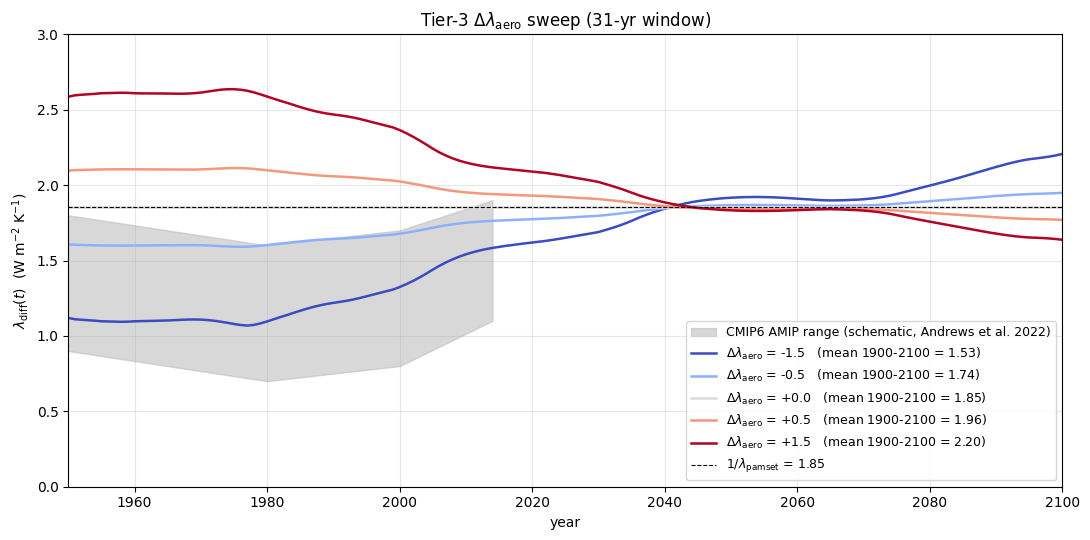

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ref_years = np.array([1870, 1950, 1980, 2000, 2014])
ref_lo    = np.array([1.4,  0.9,  0.7,  0.8,  1.1])
ref_hi    = np.array([2.0,  1.8,  1.6,  1.7,  1.9])
ax.fill_between(ref_years, ref_lo, ref_hi, color='0.75', alpha=0.6,
                label='CMIP6 AMIP range (schematic, Andrews et al. 2022)')

cmap = plt.get_cmap('coolwarm')
n = len(dl_values)
for i, dl in enumerate(dl_values):
    c = cmap(i / max(1, n - 1))
    ax.plot(years, ld[dl], color=c, lw=1.8,
            label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}   (mean 1900-2100 = {np.nanmean(ld[dl][mask_hist]):.2f})')

ax.axhline(1.0 / LAMBDA_PAMSET, color='k', ls='--', lw=0.8,
           label=rf'$1/\lambda_\mathrm{{pamset}}$ = {1/LAMBDA_PAMSET:.2f}')
ax.set_xlim(1950, 2100)
ax.set_ylim(0.0, 3)
ax.set_xlabel('year')
ax.set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$)')
ax.set_title(rf'Tier-3 $\Delta\lambda_\mathrm{{aero}}$ sweep ({WINDOW}-yr window)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

## The discriminating test — scatter against $w_\text{aero}$

Tier 1 (notebook 02) showed weak, signed-inconsistent correlations with $w_\text{aero}$ because the variation came from $dF_\text{aero}/dT$. Tier 3 encodes $w_\text{aero}$ directly into the feedback, so we expect **clean monotonic lines** here — one per $\Delta\lambda_\text{aero}$, with slope equal to $\Delta\lambda_\text{aero}$ to leading order.

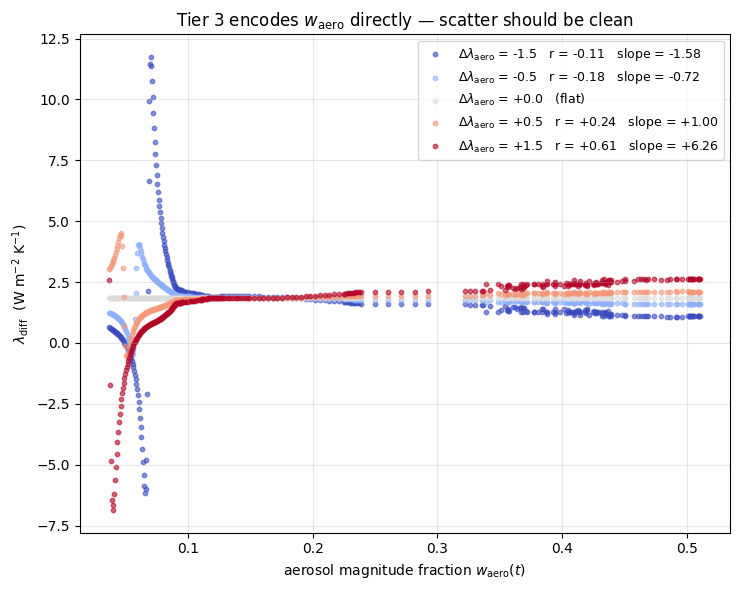

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6))

scatter_mask = ~np.isnan(ld[0.0]) & (years >= 1900) & (years <= 2200)
x = w_aero.loc[years[scatter_mask]].values

cmap = plt.get_cmap('coolwarm')
for i, dl in enumerate(dl_values):
    c = cmap(i / max(1, len(dl_values) - 1))
    y = ld[dl][scatter_mask]
    if np.std(y) > 1e-10:
        r_val = np.corrcoef(x, y)[0, 1]
        slope, intercept = np.polyfit(x, y, 1)
        lbl = rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}   r = {r_val:+.2f}   slope = {slope:+.2f}'
    else:
        lbl = rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}   (flat)'
    ax.scatter(x, y, s=10, color=c, alpha=0.6, label=lbl)

ax.set_xlabel(r'aerosol magnitude fraction $w_\mathrm{aero}(t)$')
ax.set_ylabel(r'$\lambda_\mathrm{diff}$  (W m$^{-2}$ K$^{-1}$)')
ax.set_title('Tier 3 encodes $w_\\mathrm{aero}$ directly — scatter should be clean')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

## Temperature response

$\Delta\lambda_\text{aero} > 0$ makes the feedback stronger during the aerosol era → more effective damping → less warming at peak aerosol loading. $\Delta\lambda_\text{aero} < 0$ does the opposite.

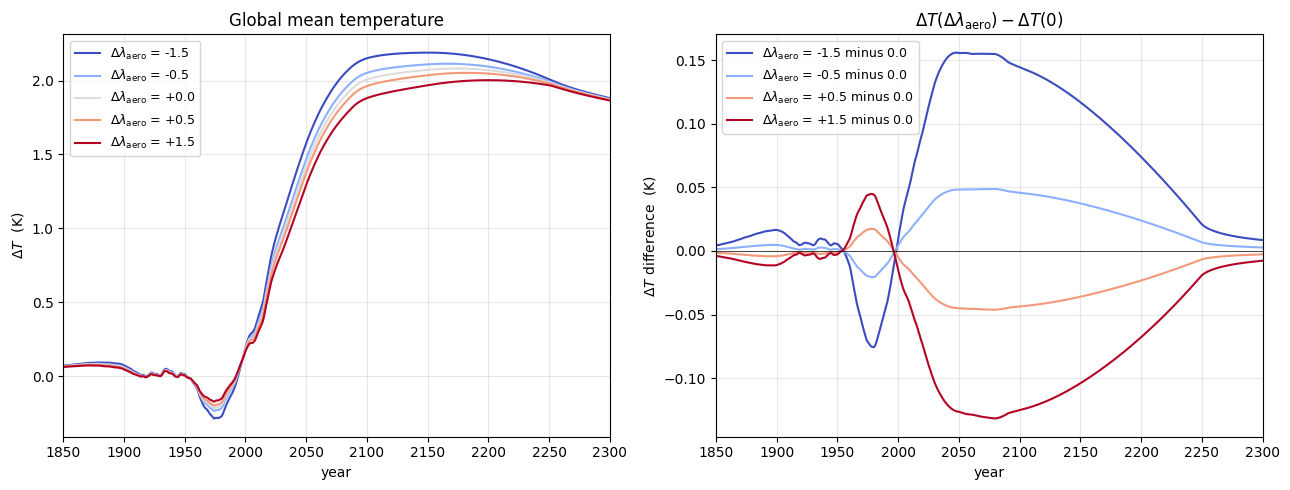

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cmap = plt.get_cmap('coolwarm')
for i, dl in enumerate(dl_values):
    c = cmap(i / max(1, len(dl_values) - 1))
    ax[0].plot(years, runs[dl]['T'], color=c, lw=1.5, label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}')

ax[0].set_xlim(1850, 2300); ax[0].set_xlabel('year'); ax[0].set_ylabel(r'$\Delta T$  (K)')
ax[0].set_title('Global mean temperature')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

for i, dl in enumerate(dl_values):
    if dl == 0.0:
        continue
    c = cmap(i / max(1, len(dl_values) - 1))
    ax[1].plot(years, runs[dl]['T'] - runs[0.0]['T'], color=c, lw=1.5,
               label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f} minus 0.0')

ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xlim(1850, 2300); ax[1].set_xlabel('year'); ax[1].set_ylabel(r'$\Delta T$ difference  (K)')
ax[1].set_title(r'$\Delta T(\Delta\lambda_\mathrm{aero}) - \Delta T(0)$')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Interpretation and next step

**Expected signature (to confirm from the plots above):**
- Each $\Delta\lambda_\text{aero}$ produces a $\lambda_\text{diff}(t)$ that qualitatively tracks the aerosol-fraction trajectory — rising (or falling, depending on sign) during the aerosol peak and returning toward $1/\lambda_\text{pamset}$ by $\sim$2100 as $w_\text{aero} \to 0$.
- The scatter against $w_\text{aero}$ should be a clean, sign-consistent line per $\Delta\lambda_\text{aero}$, with slope close to $\Delta\lambda_\text{aero}$ itself. This is the direct tell that Tier 3 has a structural coupling between feedback and forcing composition, whereas Tier 1 only had a spurious one through $dF_\text{aero}/dT$.
- Negative $\Delta\lambda_\text{aero}$ gives the sign of variation seen in CMIP6 AMIP diagnostics (weaker feedback during the aerosol era).

**Prototype caveats — same as notebook 02 plus a few new ones:**
- $F_\text{eff}$ and $w_\text{aero}$ are global only; no hemispheric asymmetry. Aerosols are ~90% NH in CICERO-SCM's hemispheric routing, so a regional extension would tilt the feedback shift toward NH cloud sensitivity.
- $w_\text{aero}(t)$ is precomputed from a baseline emissions run and held fixed. In a fully coupled implementation, the feedback change would feed back into emissions-driven concentrations too — not a concern for rf_run prototype.
- The subclass writes into `self.pamset['rlamda']`/`fnx`/`fsx` in-place. For a production version we'd add a named field (e.g. `rlamda_baseline` stored separately) so that later code that reads `pamset['lambda']` for diagnostics still returns the nominal parameter rather than the last year's $\lambda_\text{eff}$.
- `ocean_efficacy` is 1.0 throughout; any non-flat $\lambda_\text{diff}(t)$ traces to the Tier-3 coupling.

**Source-code promotion path** (for when we want to ship this, not just prototype):
1. Add `delta_lambda_aero` to `thermal_model_required_pamset` in both `upwelling_diffusion_model.py` and `two_layer_ocean.py`.
2. Modify `energy_budget` in each to accept a per-agent forcing snapshot (or a precomputed $w_\text{aero}$) alongside the hemispheric forcing.
3. Propagate this through `ciceroscm.py`'s main loop: `ce_handler.conc2forc` already exposes `self.forc` keyed by tracer, so the aerosol fraction can be computed there and passed to `energy_budget`.
4. In rf_run mode, if no per-agent decomposition is available from the forcing file, fall back to $w_\text{aero} = 0$ (equivalent to baseline) or require a forcing file with per-agent columns.

**Next notebook:** `04_calibration_sketch.ipynb` — given the Tier 1 + Tier 3 knobs, what CMIP6 and observational targets cleanly separate them, and what ranges of $(E_\text{aero},\,\Delta\lambda_\text{aero})$ are consistent with historical ECS / $\lambda_\text{diff}$ time series?